In [4]:
import pandas as pd

df_load = pd.read_csv("../data/Load_2022_clean.csv")
df_pv = pd.read_csv("../data/PV_2022_clean.csv")
df_weather = pd.read_csv("../data/Weather_clean_NEMS.csv")

In [5]:
df_load.head()

,TimestampInUtc,House1,House2,House3,Sum
0,2021-12-31 23:00,4.687989,13.361136,3.210137,21.259262
1,2021-12-31 23:15,5.775093,10.841218,3.185691,19.802003
2,2021-12-31 23:30,5.579068,4.176180,3.106543,12.861791
3,2021-12-31 23:45,6.073584,4.377591,11.027538,21.478712
4,2022-01-01 00:00,10.755348,6.999270,9.518171,27.272789


In [6]:
df_pv.head()

,TimestampInUtc,PV
0,2021-12-31 23:00,0.0
1,2021-12-31 23:15,0.0
2,2021-12-31 23:30,0.0
3,2021-12-31 23:45,0.0
4,2022-01-01 00:00,0.0


In [7]:
df_weather.head()

,timestamp,Temperature,Sunshine Duration,Shortwave Radiation,Direct Shortwave Radiation,Diffuse Shortwave Radiation,Snowfall Amount,Relative Humidity,Cloud Cover Total
0,2022-01-01 00:00:00,9.657269,0.0,0.0,0.0,0.0,0.0,29.0,0.0
1,2022-01-01 01:00:00,9.457270,0.0,0.0,0.0,0.0,0.0,29.0,0.0
2,2022-01-01 02:00:00,9.787270,0.0,0.0,0.0,0.0,0.0,28.0,0.0
3,2022-01-01 03:00:00,9.467270,0.0,0.0,0.0,0.0,0.0,28.0,0.0
4,2022-01-01 04:00:00,8.797270,0.0,0.0,0.0,0.0,0.0,30.0,0.0


In [9]:
!pip install matplotlib
!pip install seaborn

  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp311-cp311-win_amd64.whl.metadata (6.4 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------- ----------------------------- 2.1/8.1 MB 10.7 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.1 MB 13.3 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 14.8 MB/s  0:00:00
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 16.6 MB/s  0:00:00
Using cached kiwisolver-1.4.9-cp311-cp311-win_amd64.whl (73 kB)
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   -------------------- ------------------- 3.7/7.0 MB 18.2 MB/s eta 0:00:01
   ---------------

In [12]:
print(df_weather.columns)
print(df_weather.index.name)


Index(['Temperature', 'Sunshine Duration', 'Shortwave Radiation',
       'Direct Shortwave Radiation', 'Diffuse Shortwave Radiation',
       'Snowfall Amount', 'Relative Humidity', 'Cloud Cover Total'],
      dtype='str')
timestamp


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# ensure datetime index
df_load = df_load.copy()

if "TimestampInUtc" in df_load.columns:
    df_load["TimestampInUtc"] = pd.to_datetime(df_load["TimestampInUtc"], errors="coerce")
    df_load = df_load.dropna(subset=["TimestampInUtc"])
    df_load = df_load.set_index("TimestampInUtc")
else:
    if not isinstance(df_load.index, pd.DatetimeIndex):
        df_load.index = pd.to_datetime(df_load.index, errors="coerce")
        df_load = df_load.loc[df_load.index.notna()]


In [17]:
nan_count = df_load.isna().sum()
nan_pct = (df_load.isna().mean() * 100).round(2)

nan_summary = (
    pd.DataFrame({"nan_count": nan_count, "nan_pct": nan_pct})
    .sort_values("nan_count", ascending=False)
)

nan_summary


,nan_count,nan_pct
House1,3,0.01
House2,3,0.01
House3,3,0.01
Sum,3,0.01


In [19]:
df_load_filled = df_load.copy()

numeric_cols = df_load_filled.select_dtypes(include="number").columns

df_load_filled[numeric_cols] = df_load_filled[numeric_cols].interpolate(
    method="time",
    limit_direction="both"
)

# Optional: if you want to be strict and still forward-fill any remaining edge cases
df_load_filled[numeric_cols] = df_load_filled[numeric_cols].ffill().bfill()

# check remaining NaNs
df_load_filled.isna().sum().sort_values(ascending=False)


House1    0
House2    0
House3    0
Sum       0
dtype: int64

In [20]:
#Recompute sum
house_cols = [c for c in ["House1", "House2", "House3"] if c in df_load_filled.columns]

if len(house_cols) > 0:
    df_load_filled["Sum"] = df_load_filled[house_cols].sum(axis=1)


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

def ensure_datetime_index(df: pd.DataFrame, candidates: list[str]) -> pd.DataFrame:
    df = df.copy()

    if isinstance(df.index, pd.DatetimeIndex):
        return df

    time_col = None
    for c in candidates:
        if c in df.columns:
            time_col = c
            break

    if time_col is None:
        first_col = df.columns[0]
        time_col = first_col

    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
    df = df.dropna(subset=[time_col])
    df = df.set_index(time_col)
    return df

# --- ensure datetime index for each ---
df_weather = ensure_datetime_index(df_weather, ["timestamp", "Timestamp", "time", "date", "Date"])
df_pv      = ensure_datetime_index(df_pv,      ["TimestampInUtc", "timestamp", "Timestamp"])
df_load    = ensure_datetime_index(df_load,    ["TimestampInUtc", "timestamp", "Timestamp"])

# --- resample to hourly ---
df_pv_hour = df_pv.resample("h").mean()
df_load_hour = df_load.resample("h").mean()

# --- merge ---
df = df_weather.join(df_pv_hour, how="inner").join(df_load_hour, how="inner")

df.head()


,Temperature,Sunshine Duration,Shortwave Radiation,Direct Shortwave Radiation,Diffuse Shortwave Radiation,Snowfall Amount,Relative Humidity,Cloud Cover Total,PV,House1,House2,House3,Sum
timestamp,,,,,,,,,,,,,
2022-01-01 00:00:00,9.657269,0.0,0.0,0.0,0.0,0.0,29.0,0.0,0.0,12.010945,7.677682,7.828829,27.517455
2022-01-01 01:00:00,9.457270,0.0,0.0,0.0,0.0,0.0,29.0,0.0,0.0,6.624415,12.098659,15.910827,34.633901
2022-01-01 02:00:00,9.787270,0.0,0.0,0.0,0.0,0.0,28.0,0.0,0.0,12.303576,8.109732,17.125447,37.538755
2022-01-01 03:00:00,9.467270,0.0,0.0,0.0,0.0,0.0,28.0,0.0,0.0,15.779807,7.291059,3.225149,26.296015
2022-01-01 04:00:00,8.797270,0.0,0.0,0.0,0.0,0.0,30.0,0.0,0.0,12.096437,8.520094,2.655528,23.272059


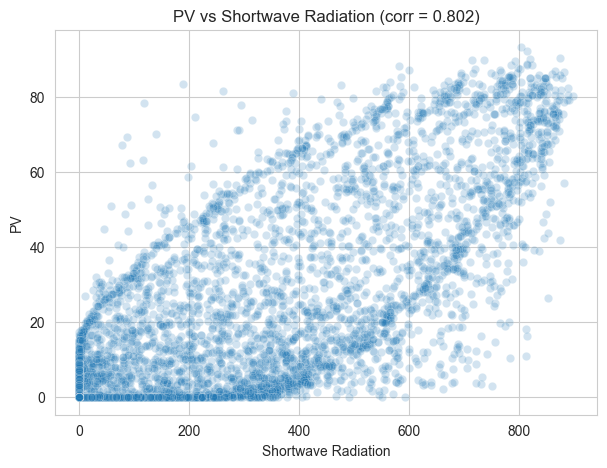

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

x = df["Shortwave Radiation"]
y = df["PV"]

# compute correlation
corr = x.corr(y)

plt.figure(figsize=(7,5))
sns.scatterplot(x=x, y=y, alpha=0.2)

plt.title(f"PV vs Shortwave Radiation (corr = {corr:.3f})")
plt.xlabel("Shortwave Radiation")
plt.ylabel("PV")

plt.show()


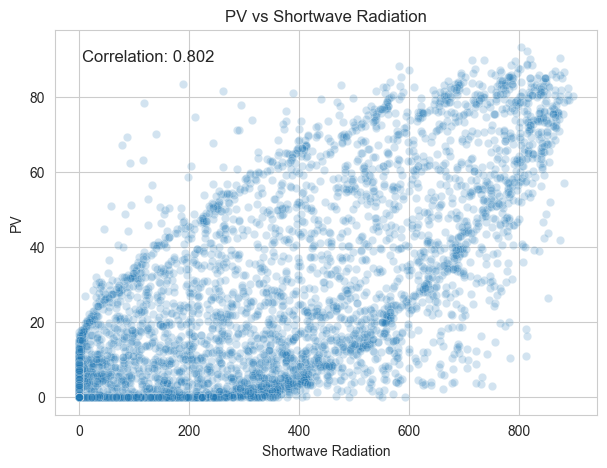

In [24]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=x, y=y, alpha=0.2)

plt.text(
    0.05, 0.95,
    f"Correlation: {corr:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top"
)

plt.title("PV vs Shortwave Radiation")
plt.show()


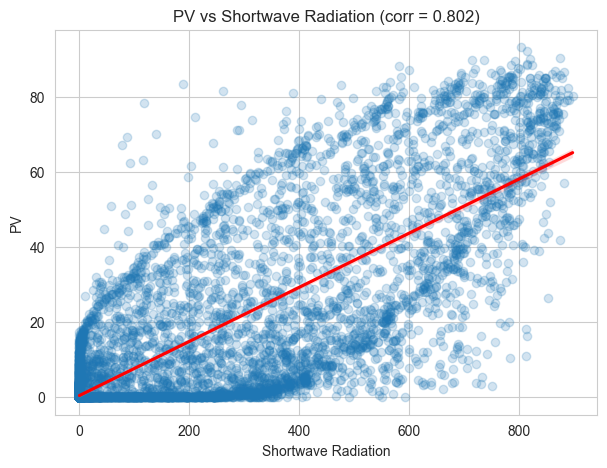

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

x1 = df["Shortwave Radiation"]
y = df["PV"]

corr1 = x1.corr(y)

plt.figure(figsize=(7,5))
sns.regplot(
    x=x1,
    y=y,
    scatter_kws={"alpha":0.2},
    line_kws={"color":"red"}
)

plt.title(f"PV vs Shortwave Radiation (corr = {corr1:.3f})")
plt.xlabel("Shortwave Radiation")
plt.ylabel("PV")
plt.show()


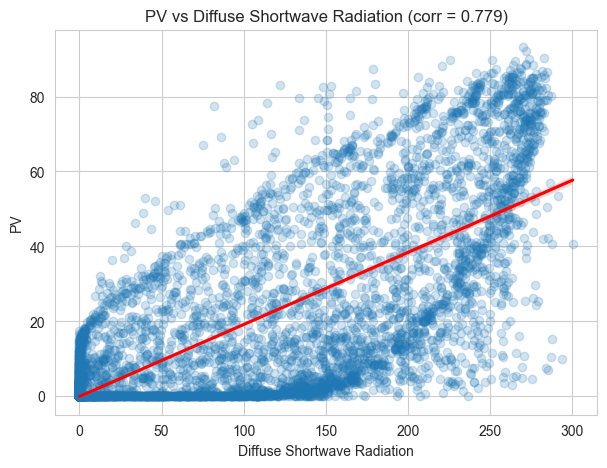

In [26]:
x2 = df["Diffuse Shortwave Radiation"]
corr2 = x2.corr(y)

plt.figure(figsize=(7,5))
sns.regplot(
    x=x2,
    y=y,
    scatter_kws={"alpha":0.2},
    line_kws={"color":"red"}
)

plt.title(f"PV vs Diffuse Shortwave Radiation (corr = {corr2:.3f})")
plt.xlabel("Diffuse Shortwave Radiation")
plt.ylabel("PV")
plt.show()


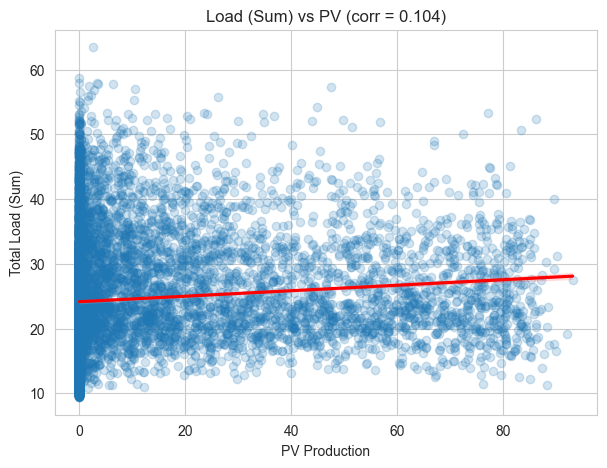

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

x = df["PV"]
y = df["Sum"]

corr = x.corr(y)

plt.figure(figsize=(7,5))
sns.regplot(
    x=x,
    y=y,
    scatter_kws={"alpha":0.2},
    line_kws={"color":"red"}
)

plt.title(f"Load (Sum) vs PV (corr = {corr:.3f})")
plt.xlabel("PV Production")
plt.ylabel("Total Load (Sum)")
plt.show()


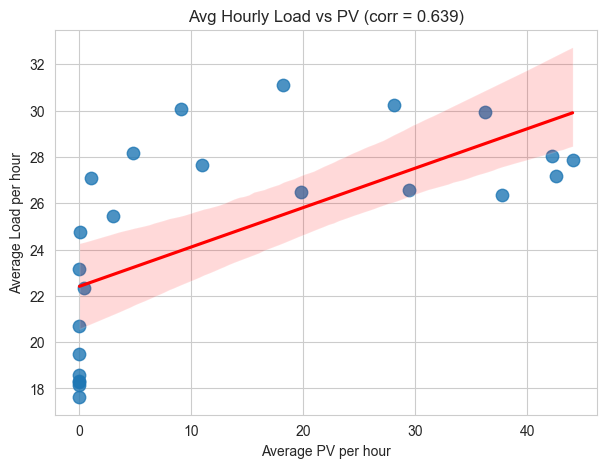

In [28]:
df["hour"] = df.index.hour
hourly = df.groupby("hour")[["PV","Sum"]].mean()

corr_hourly = hourly["PV"].corr(hourly["Sum"])

plt.figure(figsize=(7,5))
sns.regplot(
    x=hourly["PV"],
    y=hourly["Sum"],
    scatter_kws={"s":80},
    line_kws={"color":"red"}
)

plt.title(f"Avg Hourly Load vs PV (corr = {corr_hourly:.3f})")
plt.xlabel("Average PV per hour")
plt.ylabel("Average Load per hour")
plt.show()


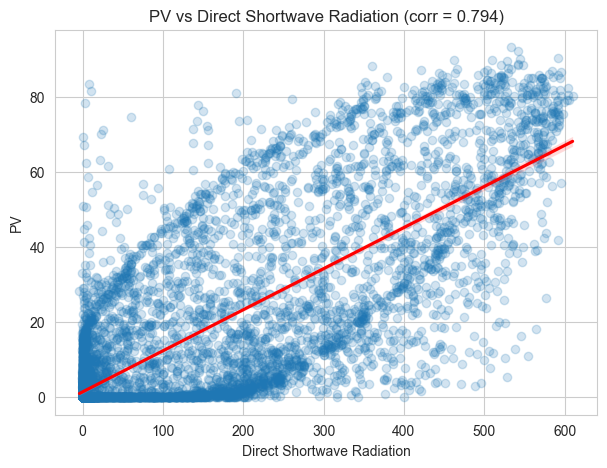

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

x = df["Direct Shortwave Radiation"]
y = df["PV"]

corr = x.corr(y)

plt.figure(figsize=(7,5))
sns.regplot(
    x=x,
    y=y,
    scatter_kws={"alpha":0.2},
    line_kws={"color":"red"}
)

plt.title(f"PV vs Direct Shortwave Radiation (corr = {corr:.3f})")
plt.xlabel("Direct Shortwave Radiation")
plt.ylabel("PV")
plt.show()


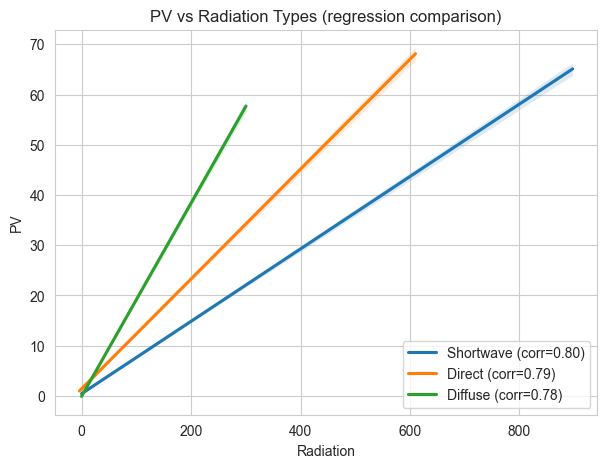

In [30]:
plt.figure(figsize=(7,5))

sns.regplot(
    x=df["Shortwave Radiation"],
    y=df["PV"],
    scatter=False,
    label=f"Shortwave (corr={df['Shortwave Radiation'].corr(df['PV']):.2f})"
)

sns.regplot(
    x=df["Direct Shortwave Radiation"],
    y=df["PV"],
    scatter=False,
    label=f"Direct (corr={df['Direct Shortwave Radiation'].corr(df['PV']):.2f})"
)

sns.regplot(
    x=df["Diffuse Shortwave Radiation"],
    y=df["PV"],
    scatter=False,
    label=f"Diffuse (corr={df['Diffuse Shortwave Radiation'].corr(df['PV']):.2f})"
)

plt.legend()
plt.title("PV vs Radiation Types (regression comparison)")
plt.xlabel("Radiation")
plt.ylabel("PV")
plt.show()


In [33]:
!pip install -U scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --------------- ------------------------ 3.1/8.1 MB 18.5 MB/s eta 0:00:01
   ----------------------------------- ---- 7.1/8.1 MB 19.0 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 17.9 MB/s  0:00:00
   ---------------------------------------- 0.0/36.4 MB ? eta -:--:--
   ---- ----------------------------------- 3.9/36.4 MB 18.1 MB/s eta 0:00:02
   -------- ------------------------------- 7.9/36.4 MB 18.7 MB/s eta 0:00:02
   ------------ --------------------------- 11.8/36.4 MB 19.5 MB/s eta 0:00:02
   ---------------- ----------------------- 15.2/36.4 MB 18.8 MB/s eta 0:00:02
   ------------------- -------------------- 17.6/36.4 MB 17.0 MB/s eta 0:00:02
   -------------------- ------------------- 18.9/36.4 MB 15.5 MB/s eta 0:00:02
   ---------------------- ----------------- 20.2/36.4 MB 13.9 MB/s eta 0:00:02
   ----------

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

df_model = df.copy()

# use only rows where radiation exists
df_model = df_model.dropna(subset=["Shortwave Radiation", "PV"])

# optional but smart: remove night
#df_model = df_model[df_model["Shortwave Radiation"] > 0]


In [42]:
train = df_model[: "2022-10-31"]
test  = df_model["2022-11-01":]


In [43]:
X_train = train[["Shortwave Radiation"]]
y_train = train["PV"]

X_test = test[["Shortwave Radiation"]]
y_test = test["PV"]

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)


In [44]:
mae = mean_absolute_error(y_test, pred)
r2  = r2_score(y_test, pred)

print("Baseline radiation model")
print("MAE:", mae)
print("R2:", r2)
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)


Baseline radiation model
MAE: 5.243484980074304
R2: -0.8323827942736326
Coefficient: 0.07291380853800186
Intercept: 0.839246240871045


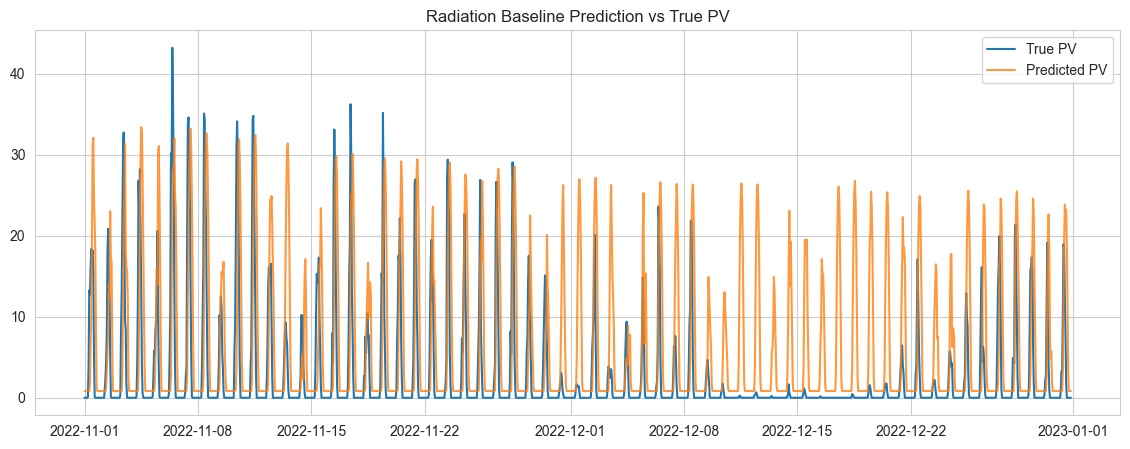

In [45]:
plt.figure(figsize=(14,5))
plt.plot(test.index, y_test, label="True PV")
plt.plot(test.index, pred, label="Predicted PV", alpha=0.8)
plt.legend()
plt.title("Radiation Baseline Prediction vs True PV")
plt.show()


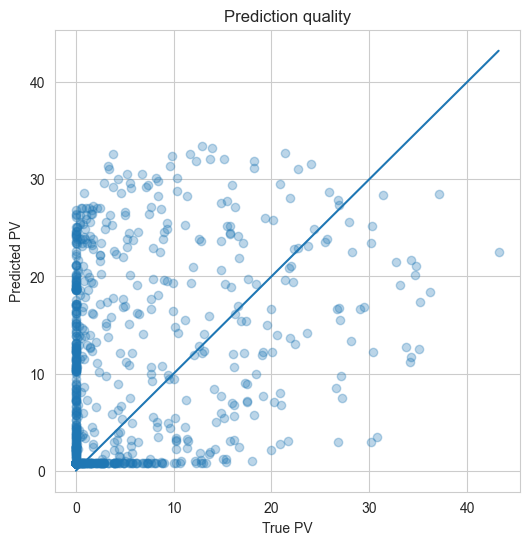

In [46]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred, alpha=0.3)
plt.xlabel("True PV")
plt.ylabel("Predicted PV")
plt.title("Prediction quality")

# perfect line
lims = [0, max(y_test.max(), pred.max())]
plt.plot(lims, lims)
plt.show()


In [ ]:



features = [
    "Shortwave Radiation",
    "Direct Shortwave Radiation",
    "Diffuse Shortwave Radiation",
    "Cloud Cover Total",
]

train = df_model[: "2022-10-31"]
test  = df_model["2022-11-01":]

model = LinearRegression()
model.fit(train[features], train["PV"])

pred = model.predict(test[features])

print("MAE:", mean_absolute_error(test["PV"], pred))
print("R2:", r2_score(test["PV"], pred))


MAE: 5.396236737067525
R2: -0.8548536240405777


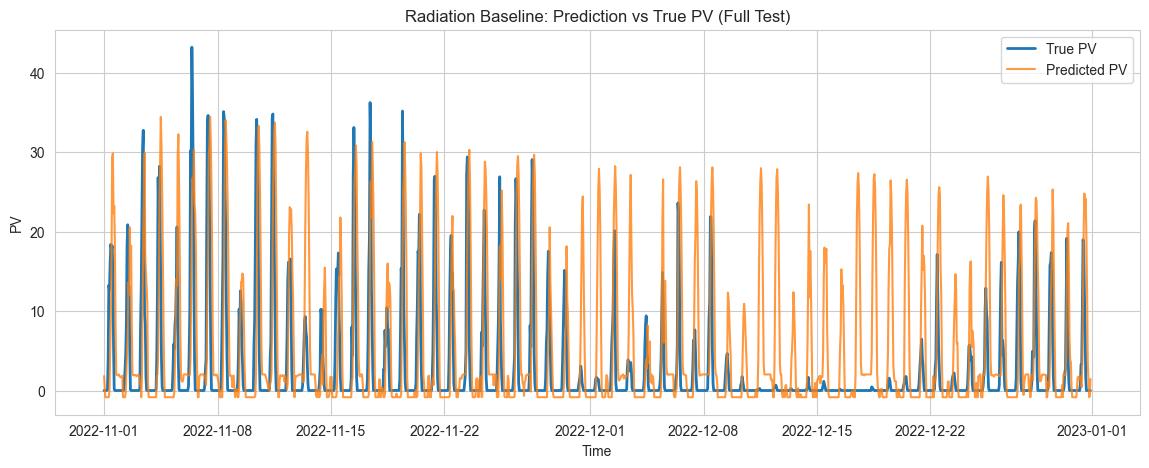

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.plot(test.index, test["PV"], label="True PV", linewidth=2)
plt.plot(test.index, pred, label="Predicted PV", alpha=0.8)

plt.title("Radiation Baseline: Prediction vs True PV (Full Test)")
plt.xlabel("Time")
plt.ylabel("PV")
plt.legend()
plt.show()


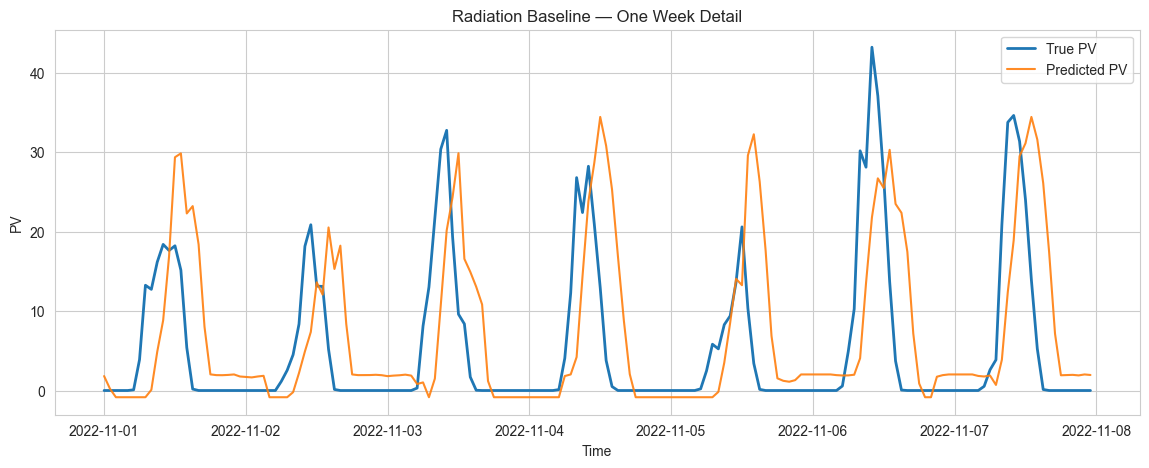

In [60]:
week = test.iloc[:24*7]   # first week (hourly)
week_pred = pred[:24*7]

plt.figure(figsize=(14,5))

plt.plot(week.index, week["PV"], label="True PV", linewidth=2)
plt.plot(week.index, week_pred, label="Predicted PV", alpha=0.9)

plt.title("Radiation Baseline — One Week Detail")
plt.xlabel("Time")
plt.ylabel("PV")
plt.legend()
plt.show()


In [63]:
df_model[df_model["PV"] < 0].head()

,Temperature,Sunshine Duration,Shortwave Radiation,Direct Shortwave Radiation,Diffuse Shortwave Radiation,Snowfall Amount,Relative Humidity,Cloud Cover Total,PV,House1,House2,House3,Sum,hour,month,dayofyear
timestamp,,,,,,,,,,,,,,,,


In [70]:



df_model["rad_lag1"] = df_model["Shortwave Radiation"].shift(1)
df_model["rad_lag2"] = df_model["Shortwave Radiation"].shift(2)



df_model = df_model.dropna()

train = df_model[: "2022-10-31"]
test  = df_model["2022-11-01":]

features = [
    "Shortwave Radiation",
    "rad_lag1",
    "rad_lag2",
    "Cloud Cover Total"
]


In [71]:
model = LinearRegression()
model.fit(train[features], train["PV"])

pred = model.predict(test[features])

pred = pred.clip(min=0)
print("MAE:", mean_absolute_error(test["PV"], pred))
print("R2:", r2_score(test["PV"], pred))

MAE: 5.557476626546857
R2: -0.9713623328290966


In [ ]:
#R2 not meaningful because of nosy daita, MAE much more important here.

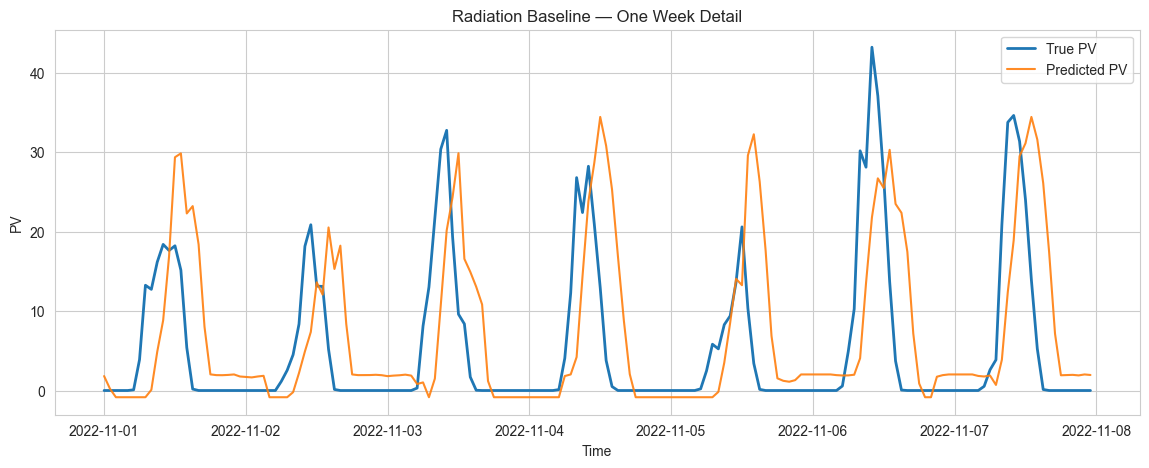